# Practical 2 — Markov Decision Processes (MDPs) with Gridworld

In the theory class you saw the **MDP framework** and the **Bellman equations**.
In this practical we will implement:

1. A small **Gridworld MDP**
2. **Policy Evaluation** (Bellman *expectation* backup)
3. **Value Iteration** (Bellman *optimality* backup)
4. A **visualization** of the value function and policy

We will use a **Sutton-style** gridworld:
- Grid: **4×4**
- Terminal states: **top-left (0,0)** and **bottom-right (3,3)**
- Reward: **-1 per step** (including bumping into walls)
- Discount factor: $\gamma = 0.9$ (slightly discounted)

What's the optimal behaviour?

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

candidate_paths = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd() / "Portfolio",
    Path.cwd() / "MIA-AR-RR" / "Portfolio",
]
for candidate in candidate_paths:
    if (candidate / "mia_rl").is_dir():
        sys.path.insert(0, str(candidate.resolve()))
        break

np.set_printoptions(precision=3, suppress=True)

from mia_rl.envs.gridworld import ACTIONS, Gridworld, TrapGridworld
from mia_rl.policies.gridworld import greedy_policy_from_V, uniform_random_policy
from mia_rl.envs.gridworld import (
    policy_evaluation,
    policy_evaluation_Q,
    policy_evaluation_with_history,
    value_iteration,
    value_iteration_stochastic,
    zeros_V,
)
from mia_rl.plots.mdp_gridworld import plot_grid_values_and_policy


## 1) Gridworld MDP

We define:
- **States**: cells \((row,column)\)
- **Actions**: `U, D, L, R`
- **Transition**: deterministic (attempted move; if off-grid you stay)
- **Reward**: -1 each step; terminal states end the episode

We will implement an `env.step(state, action)` that returns:
`next_state, reward, done_flag`

## Environment


In [2]:
env = Gridworld()
env.states()[:5], env.terminal_states


([(0, 0), (0, 1), (0, 2), (0, 3), (1, 0)], ((0, 0), (3, 3)))

### Quick sanity checks

In [3]:
# From a non-terminal, moving into a wall keeps you in place but still costs -1
print("From (0,1) with U:", env.step((0, 1), "U"))
# From a non-terminal, moving toward terminal
print("From (0,1) with L:", env.step((0, 1), "L"))
# From terminal, stay terminal
print("From (0,0) with R:", env.step((0, 0), "R"))


State: (0, 1), Action: U, Delta: (-1, 0)
From (0,1) with U: ((0, 1), -1.0, False)
State: (0, 1), Action: L, Delta: (0, -1)
From (0,1) with L: ((0, 0), -1.0, True)
From (0,0) with R: ((0, 0), 0.0, True)


## 2) Utilities: indexing states and initializing V

We'll store $V$ as a 2D array `V[r,c]`.

In [4]:
V0 = zeros_V(env)
V0

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

## 3) Policy definition

We start with a **uniform random policy**:
$\pi(a\mid s)=\frac{1}{4}$ for all non-terminal states.

In [5]:
policy = uniform_random_policy(env)
policy[(1,1)]

{'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25}

## 4) Policy Evaluation (compute $V^{\pi}$)

Bellman expectation backup:

$
V(s) \leftarrow \sum_a \pi(a|s)\left[r(s,a) + \gamma V(s')\right]
$

### ✅ Your task
Fill in the two TODOs:
1. Compute the expected update for a single state (`bellman_expectation_update`)
2. Run iterative policy evaluation (`policy_evaluation`)

In [6]:
gamma = 0.9
V_pi, iters = policy_evaluation(env, policy, gamma=gamma, theta=1e-8)
print("Converged in iterations:", iters)
V_pi

State: (0, 1), Action: U, Delta: (-1, 0)
State: (0, 1), Action: D, Delta: (1, 0)
State: (0, 1), Action: L, Delta: (0, -1)
State: (0, 1), Action: R, Delta: (0, 1)
State: (0, 2), Action: U, Delta: (-1, 0)
State: (0, 2), Action: D, Delta: (1, 0)
State: (0, 2), Action: L, Delta: (0, -1)
State: (0, 2), Action: R, Delta: (0, 1)
State: (0, 3), Action: U, Delta: (-1, 0)
State: (0, 3), Action: D, Delta: (1, 0)
State: (0, 3), Action: L, Delta: (0, -1)
State: (0, 3), Action: R, Delta: (0, 1)
State: (1, 0), Action: U, Delta: (-1, 0)
State: (1, 0), Action: D, Delta: (1, 0)
State: (1, 0), Action: L, Delta: (0, -1)
State: (1, 0), Action: R, Delta: (0, 1)
State: (1, 1), Action: U, Delta: (-1, 0)
State: (1, 1), Action: D, Delta: (1, 0)
State: (1, 1), Action: L, Delta: (0, -1)
State: (1, 1), Action: R, Delta: (0, 1)
State: (1, 2), Action: U, Delta: (-1, 0)
State: (1, 2), Action: D, Delta: (1, 0)
State: (1, 2), Action: L, Delta: (0, -1)
State: (1, 2), Action: R, Delta: (0, 1)
State: (1, 3), Action: U, De

array([[ 0.   , -5.278, -7.128, -7.651],
       [-5.278, -6.606, -7.181, -7.128],
       [-7.128, -7.181, -6.606, -5.278],
       [-7.651, -7.128, -5.278,  0.   ]])

State: (0, 1), Action: U, Delta: (-1, 0)
State: (0, 1), Action: D, Delta: (1, 0)
State: (0, 1), Action: L, Delta: (0, -1)
State: (0, 1), Action: R, Delta: (0, 1)
State: (0, 2), Action: U, Delta: (-1, 0)
State: (0, 2), Action: D, Delta: (1, 0)
State: (0, 2), Action: L, Delta: (0, -1)
State: (0, 2), Action: R, Delta: (0, 1)
State: (0, 3), Action: U, Delta: (-1, 0)
State: (0, 3), Action: D, Delta: (1, 0)
State: (0, 3), Action: L, Delta: (0, -1)
State: (0, 3), Action: R, Delta: (0, 1)
State: (1, 0), Action: U, Delta: (-1, 0)
State: (1, 0), Action: D, Delta: (1, 0)
State: (1, 0), Action: L, Delta: (0, -1)
State: (1, 0), Action: R, Delta: (0, 1)
State: (1, 1), Action: U, Delta: (-1, 0)
State: (1, 1), Action: D, Delta: (1, 0)
State: (1, 1), Action: L, Delta: (0, -1)
State: (1, 1), Action: R, Delta: (0, 1)
State: (1, 2), Action: U, Delta: (-1, 0)
State: (1, 2), Action: D, Delta: (1, 0)
State: (1, 2), Action: L, Delta: (0, -1)
State: (1, 2), Action: R, Delta: (0, 1)
State: (1, 3), Action: U, De

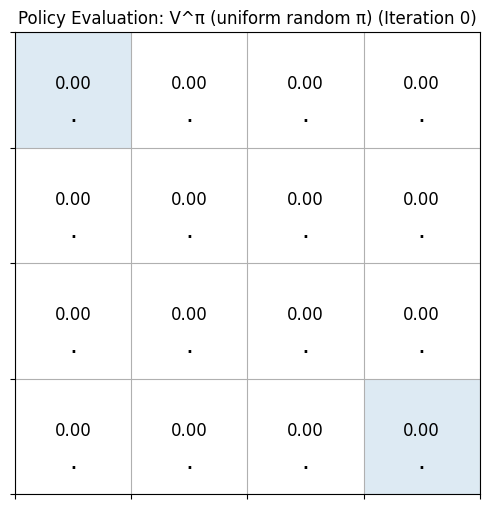

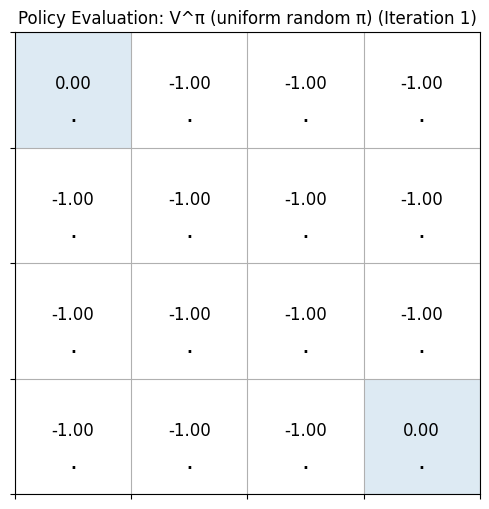

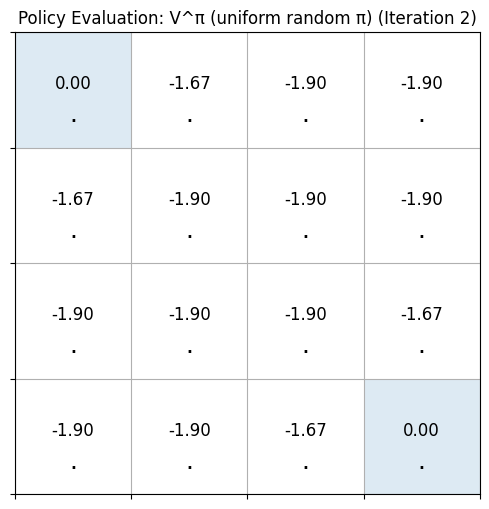

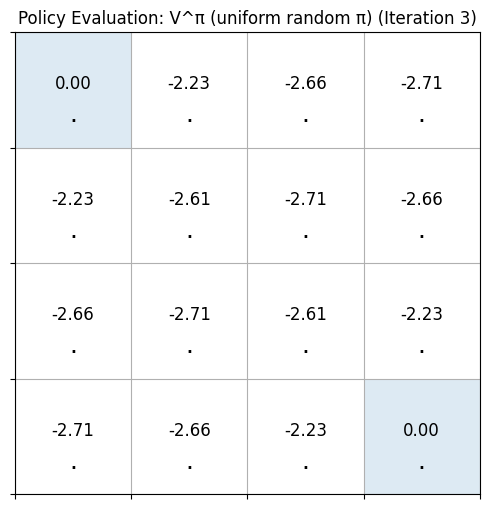

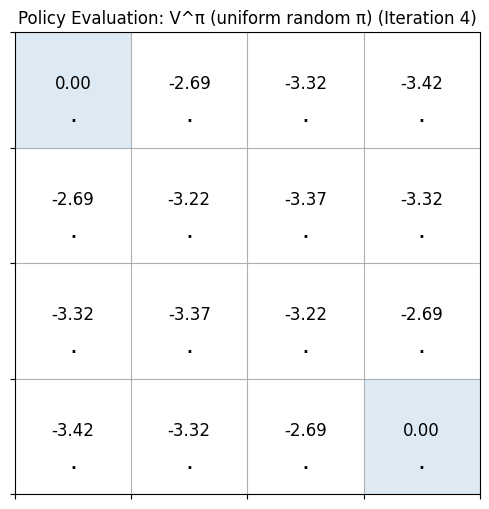

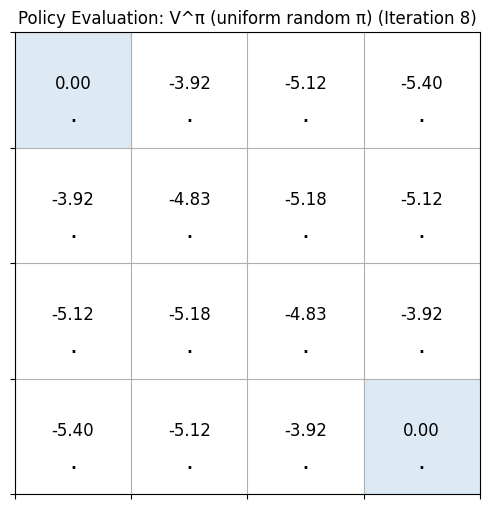

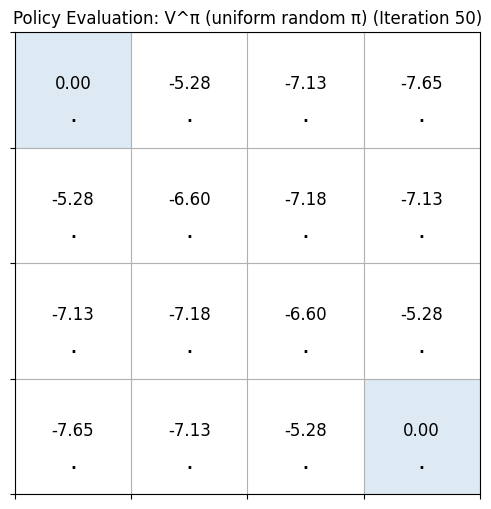

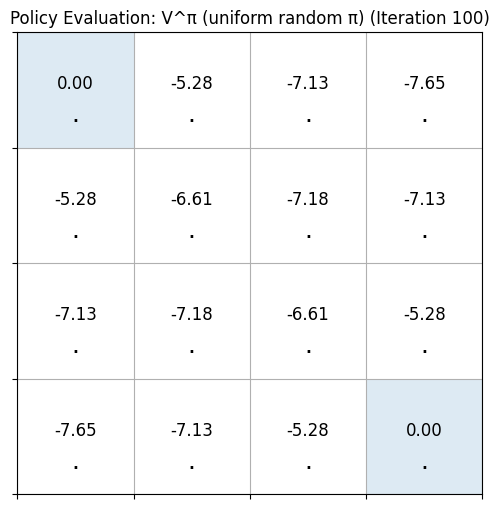

In [7]:
V_pi_hist, it_pi_hist = policy_evaluation_with_history(env, policy, gamma=gamma, theta=1e-8)

# For policy evaluation, the policy is fixed (uniform random), so we don't need to derive it from V.
# However, the plot_grid_values_and_policy expects a single action per state for arrows.
# For a uniform random policy, we can choose not to show arrows or represent them as '·'.
# Let's create a placeholder policy that always shows '·' for non-terminal states.
plot_policy_for_pe = {
    s: '·' if env.is_terminal(s) else '?' for s in env.states()
}

# User-requested specific iterations to plot
specific_iterations = [0, 1, 2, 3, 4, 8, 50, 100]

# Filter out iterations that are beyond the actual history length
indices_to_plot = sorted(list(set([it for it in specific_iterations if it < len(V_pi_hist)])))

for i in indices_to_plot:
    current_V_pi = V_pi_hist[i]
    current_it_pi = it_pi_hist[i]
    plot_grid_values_and_policy(
        env, current_V_pi, plot_policy_for_pe,
        title=f"Policy Evaluation: V^π (uniform random π) (Iteration {current_it_pi})"
    )

## 5) Value Iteration (approximate $V^{*}$)

Bellman optimality backup:

$
V(s) \leftarrow \max_a \left[r(s,a) + \gamma V(s')\right]
$

We then extract a greedy policy:
$\pi(s)=\arg\max_a\,[r(s,a)+\gamma V(s')]$

In [8]:
V_star, iters_vi = value_iteration(env, gamma=gamma, theta=1e-8)
print("Converged in iterations:", iters_vi)
V_star

State: (0, 1), Action: U, Delta: (-1, 0)
State: (0, 1), Action: D, Delta: (1, 0)
State: (0, 1), Action: L, Delta: (0, -1)
State: (0, 1), Action: R, Delta: (0, 1)
State: (0, 2), Action: U, Delta: (-1, 0)
State: (0, 2), Action: D, Delta: (1, 0)
State: (0, 2), Action: L, Delta: (0, -1)
State: (0, 2), Action: R, Delta: (0, 1)
State: (0, 3), Action: U, Delta: (-1, 0)
State: (0, 3), Action: D, Delta: (1, 0)
State: (0, 3), Action: L, Delta: (0, -1)
State: (0, 3), Action: R, Delta: (0, 1)
State: (1, 0), Action: U, Delta: (-1, 0)
State: (1, 0), Action: D, Delta: (1, 0)
State: (1, 0), Action: L, Delta: (0, -1)
State: (1, 0), Action: R, Delta: (0, 1)
State: (1, 1), Action: U, Delta: (-1, 0)
State: (1, 1), Action: D, Delta: (1, 0)
State: (1, 1), Action: L, Delta: (0, -1)
State: (1, 1), Action: R, Delta: (0, 1)
State: (1, 2), Action: U, Delta: (-1, 0)
State: (1, 2), Action: D, Delta: (1, 0)
State: (1, 2), Action: L, Delta: (0, -1)
State: (1, 2), Action: R, Delta: (0, 1)
State: (1, 3), Action: U, De

array([[ 0.  , -1.  , -1.9 , -2.71],
       [-1.  , -1.9 , -2.71, -1.9 ],
       [-1.9 , -2.71, -1.9 , -1.  ],
       [-2.71, -1.9 , -1.  ,  0.  ]])

In [9]:
pi_star = greedy_policy_from_V(env, V_star, gamma=gamma)
pi_star[(2,2)], pi_star[(0,1)], pi_star[(1,0)]

State: (0, 1), Action: U, Delta: (-1, 0)
State: (0, 1), Action: D, Delta: (1, 0)
State: (0, 1), Action: L, Delta: (0, -1)
State: (0, 1), Action: R, Delta: (0, 1)
State: (0, 2), Action: U, Delta: (-1, 0)
State: (0, 2), Action: D, Delta: (1, 0)
State: (0, 2), Action: L, Delta: (0, -1)
State: (0, 2), Action: R, Delta: (0, 1)
State: (0, 3), Action: U, Delta: (-1, 0)
State: (0, 3), Action: D, Delta: (1, 0)
State: (0, 3), Action: L, Delta: (0, -1)
State: (0, 3), Action: R, Delta: (0, 1)
State: (1, 0), Action: U, Delta: (-1, 0)
State: (1, 0), Action: D, Delta: (1, 0)
State: (1, 0), Action: L, Delta: (0, -1)
State: (1, 0), Action: R, Delta: (0, 1)
State: (1, 1), Action: U, Delta: (-1, 0)
State: (1, 1), Action: D, Delta: (1, 0)
State: (1, 1), Action: L, Delta: (0, -1)
State: (1, 1), Action: R, Delta: (0, 1)
State: (1, 2), Action: U, Delta: (-1, 0)
State: (1, 2), Action: D, Delta: (1, 0)
State: (1, 2), Action: L, Delta: (0, -1)
State: (1, 2), Action: R, Delta: (0, 1)
State: (1, 3), Action: U, De

('D', 'L', 'U')

In [10]:
pi_star

{(0, 0): '·',
 (0, 1): 'L',
 (0, 2): 'L',
 (0, 3): 'D',
 (1, 0): 'U',
 (1, 1): 'U',
 (1, 2): 'U',
 (1, 3): 'D',
 (2, 0): 'U',
 (2, 1): 'U',
 (2, 2): 'D',
 (2, 3): 'D',
 (3, 0): 'U',
 (3, 1): 'R',
 (3, 2): 'R',
 (3, 3): '·'}

## 5.5) Compute the action-value function $Q^{\pi}$

So far, we computed **state-value functions**.
We now introduce the **action-value function**.

For a deterministic environment, the Bellman expectation equation for $Q^{\pi}$ is:

$$
Q^{\pi}(s,a) = r(s,a) + \gamma \sum_{a'} \pi(a'\mid s')\,Q^{\pi}(s',a')
$$

where $(s', r, done) = \texttt{step}(s,a)$.

We'll implement **iterative evaluation of $Q^{\pi}$** and verify:

$$
V^{\pi}(s) = \sum_a \pi(a\mid s)\,Q^{\pi}(s,a)
$$

In [11]:
Q_pi, itq = policy_evaluation_Q(env, policy, gamma=gamma, theta=1e-8)
print("Q^pi converged in iterations:", itq)

# Verify V^pi(s) = sum_a pi(a|s) Q^pi(s,a)
V_from_Q = zeros_V(env)
for (r,c) in env.states():
    s = (r,c)
    if env.is_terminal(s):
        V_from_Q[r,c] = 0.0
    else:
        V_from_Q[r,c] = sum(policy[s][a]*Q_pi[r,c,a_index] for a_index,a in enumerate(ACTIONS))

print("max |V_pi - V_from_Q| =", np.max(np.abs(V_pi - V_from_Q)))

State: (0, 1), Action: U, Delta: (-1, 0)
State: (0, 1), Action: D, Delta: (1, 0)
State: (0, 1), Action: L, Delta: (0, -1)
State: (0, 1), Action: R, Delta: (0, 1)
State: (0, 2), Action: U, Delta: (-1, 0)
State: (0, 2), Action: D, Delta: (1, 0)
State: (0, 2), Action: L, Delta: (0, -1)
State: (0, 2), Action: R, Delta: (0, 1)
State: (0, 3), Action: U, Delta: (-1, 0)
State: (0, 3), Action: D, Delta: (1, 0)
State: (0, 3), Action: L, Delta: (0, -1)
State: (0, 3), Action: R, Delta: (0, 1)
State: (1, 0), Action: U, Delta: (-1, 0)
State: (1, 0), Action: D, Delta: (1, 0)
State: (1, 0), Action: L, Delta: (0, -1)
State: (1, 0), Action: R, Delta: (0, 1)
State: (1, 1), Action: U, Delta: (-1, 0)
State: (1, 1), Action: D, Delta: (1, 0)
State: (1, 1), Action: L, Delta: (0, -1)
State: (1, 1), Action: R, Delta: (0, 1)
State: (1, 2), Action: U, Delta: (-1, 0)
State: (1, 2), Action: D, Delta: (1, 0)
State: (1, 2), Action: L, Delta: (0, -1)
State: (1, 2), Action: R, Delta: (0, 1)
State: (1, 3), Action: U, De

## 6) Visualization

We will visualize:
- The value function as numbers inside the grid
- A policy as arrows

This is the part that makes Bellman backups “click”.

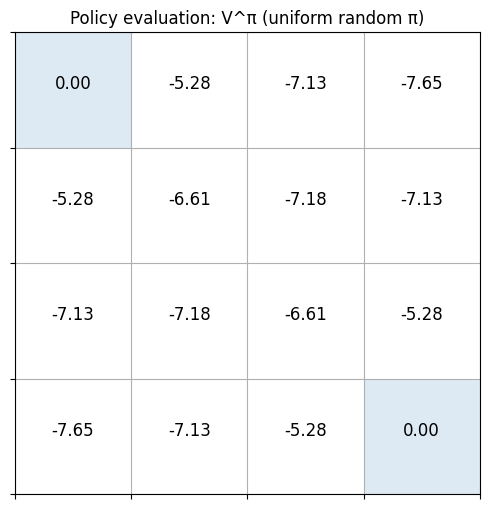

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Policy evaluation: V^π (uniform random π)'}>)

In [12]:
plot_grid_values_and_policy(env, V_pi, None, title="Policy evaluation: V^π (uniform random π)")

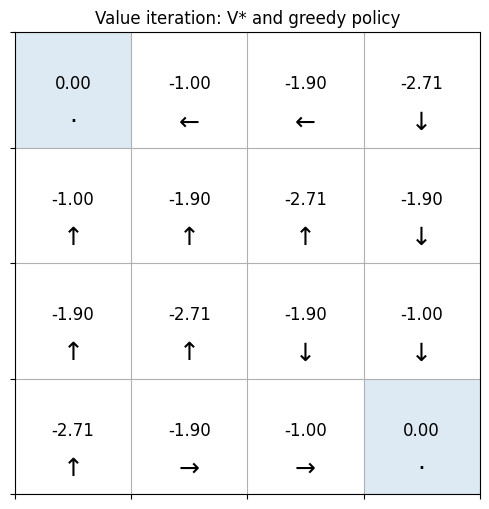

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Value iteration: V* and greedy policy'}>)

In [13]:
plot_grid_values_and_policy(env, V_star, pi_star, title="Value iteration: V* and greedy policy")

Given that both terminal states are equally far from (3,0) and (0,3), why does the optimal policy move vertically rather than horizontally in those states?

## 7) Exercises

### Exercise A — Change $\gamma$ and observe
- Try `gamma = 0.5` and `gamma = 0.99`. Re-run policy evaluation and value iteration.
- What changes in the value magnitude and the implied behaviour?

- Smaller $\gamma$ (e.g., 0.5): the agent values the future less, so **magnitudes shrink** (less negative far away).
  The *direction* of the optimal policy is usually unchanged here (still “shortest path”), but values drop off faster.
- Larger $\gamma$ (e.g., 0.99): the agent values long-term rewards more, so **magnitudes grow** (more negative far away),
  because it effectively “counts” many future step costs.

State: (0, 1), Action: U, Delta: (-1, 0)
State: (0, 1), Action: D, Delta: (1, 0)
State: (0, 1), Action: L, Delta: (0, -1)
State: (0, 1), Action: R, Delta: (0, 1)
State: (0, 2), Action: U, Delta: (-1, 0)
State: (0, 2), Action: D, Delta: (1, 0)
State: (0, 2), Action: L, Delta: (0, -1)
State: (0, 2), Action: R, Delta: (0, 1)
State: (0, 3), Action: U, Delta: (-1, 0)
State: (0, 3), Action: D, Delta: (1, 0)
State: (0, 3), Action: L, Delta: (0, -1)
State: (0, 3), Action: R, Delta: (0, 1)
State: (1, 0), Action: U, Delta: (-1, 0)
State: (1, 0), Action: D, Delta: (1, 0)
State: (1, 0), Action: L, Delta: (0, -1)
State: (1, 0), Action: R, Delta: (0, 1)
State: (1, 1), Action: U, Delta: (-1, 0)
State: (1, 1), Action: D, Delta: (1, 0)
State: (1, 1), Action: L, Delta: (0, -1)
State: (1, 1), Action: R, Delta: (0, 1)
State: (1, 2), Action: U, Delta: (-1, 0)
State: (1, 2), Action: D, Delta: (1, 0)
State: (1, 2), Action: L, Delta: (0, -1)
State: (1, 2), Action: R, Delta: (0, 1)
State: (1, 3), Action: U, De

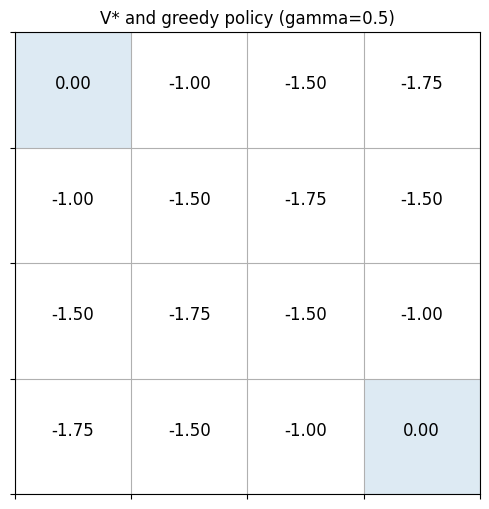

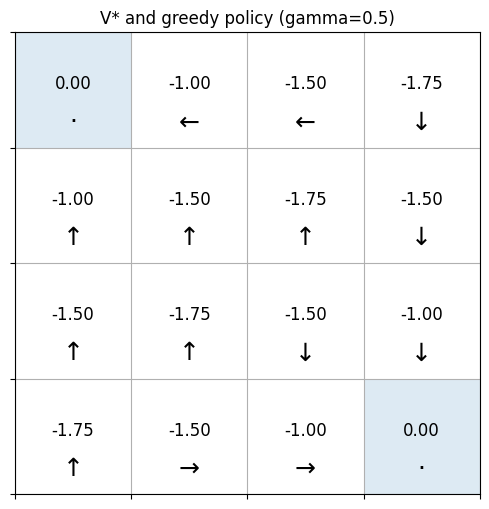

State: (0, 1), Action: U, Delta: (-1, 0)
State: (0, 1), Action: D, Delta: (1, 0)
State: (0, 1), Action: L, Delta: (0, -1)
State: (0, 1), Action: R, Delta: (0, 1)
State: (0, 2), Action: U, Delta: (-1, 0)
State: (0, 2), Action: D, Delta: (1, 0)
State: (0, 2), Action: L, Delta: (0, -1)
State: (0, 2), Action: R, Delta: (0, 1)
State: (0, 3), Action: U, Delta: (-1, 0)
State: (0, 3), Action: D, Delta: (1, 0)
State: (0, 3), Action: L, Delta: (0, -1)
State: (0, 3), Action: R, Delta: (0, 1)
State: (1, 0), Action: U, Delta: (-1, 0)
State: (1, 0), Action: D, Delta: (1, 0)
State: (1, 0), Action: L, Delta: (0, -1)
State: (1, 0), Action: R, Delta: (0, 1)
State: (1, 1), Action: U, Delta: (-1, 0)
State: (1, 1), Action: D, Delta: (1, 0)
State: (1, 1), Action: L, Delta: (0, -1)
State: (1, 1), Action: R, Delta: (0, 1)
State: (1, 2), Action: U, Delta: (-1, 0)
State: (1, 2), Action: D, Delta: (1, 0)
State: (1, 2), Action: L, Delta: (0, -1)
State: (1, 2), Action: R, Delta: (0, 1)
State: (1, 3), Action: U, De

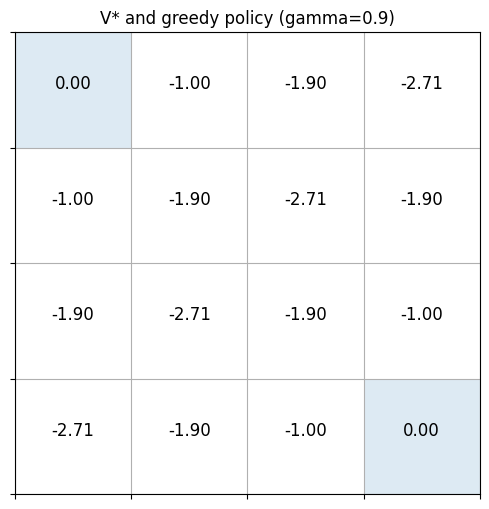

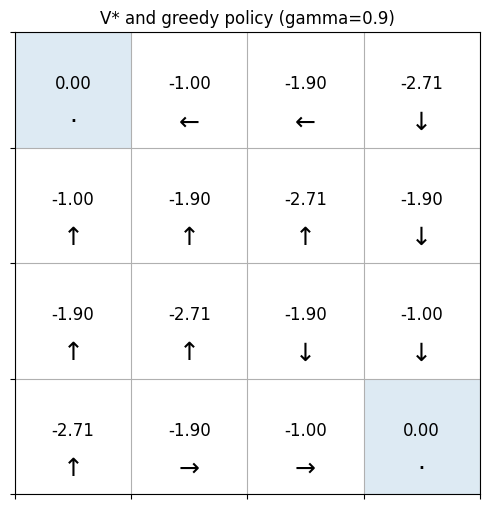

State: (0, 1), Action: U, Delta: (-1, 0)
State: (0, 1), Action: D, Delta: (1, 0)
State: (0, 1), Action: L, Delta: (0, -1)
State: (0, 1), Action: R, Delta: (0, 1)
State: (0, 2), Action: U, Delta: (-1, 0)
State: (0, 2), Action: D, Delta: (1, 0)
State: (0, 2), Action: L, Delta: (0, -1)
State: (0, 2), Action: R, Delta: (0, 1)
State: (0, 3), Action: U, Delta: (-1, 0)
State: (0, 3), Action: D, Delta: (1, 0)
State: (0, 3), Action: L, Delta: (0, -1)
State: (0, 3), Action: R, Delta: (0, 1)
State: (1, 0), Action: U, Delta: (-1, 0)
State: (1, 0), Action: D, Delta: (1, 0)
State: (1, 0), Action: L, Delta: (0, -1)
State: (1, 0), Action: R, Delta: (0, 1)
State: (1, 1), Action: U, Delta: (-1, 0)
State: (1, 1), Action: D, Delta: (1, 0)
State: (1, 1), Action: L, Delta: (0, -1)
State: (1, 1), Action: R, Delta: (0, 1)
State: (1, 2), Action: U, Delta: (-1, 0)
State: (1, 2), Action: D, Delta: (1, 0)
State: (1, 2), Action: L, Delta: (0, -1)
State: (1, 2), Action: R, Delta: (0, 1)
State: (1, 3), Action: U, De

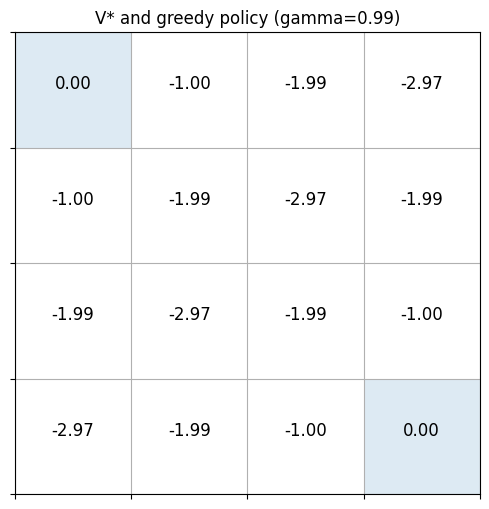

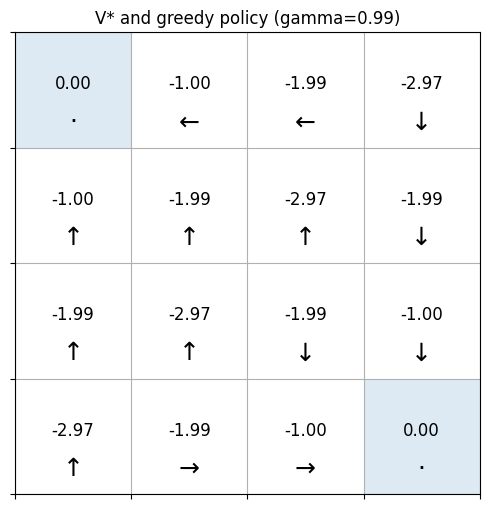

In [14]:
# Exercise A: compare gammas

for g in [0.5, 0.9, 0.99]:
    Vg, itg = value_iteration(env, gamma=g, theta=1e-8)
    pig = greedy_policy_from_V(env, Vg, gamma=g)
    print(f"\nGamma = {g} (value iteration iters={itg})")
    plot_grid_values_and_policy(env, Vg, None, title=f"V* and greedy policy (gamma={g})")
    plot_grid_values_and_policy(env, Vg, pig, title=f"V* and greedy policy (gamma={g})")

### Exercise B — Add a “trap” cell
- Pick a cell, e.g. (1,2), and make stepping *into* it give reward -10.
- How does the optimal policy change? Tip: Inherit from the Gridworld class

- Compare the number of iterations needed for policy iteration vs value iteration.

- The optimal policy will tend to **route around** the trap, even if that takes extra steps, depending on $\gamma$.
- With high $\gamma$, avoiding the trap is even more important.


State: (0, 1), Action: U, Delta: (-1, 0)
State: (0, 1), Action: D, Delta: (1, 0)
State: (0, 1), Action: L, Delta: (0, -1)
State: (0, 1), Action: R, Delta: (0, 1)
State: (0, 2), Action: U, Delta: (-1, 0)
State: (0, 2), Action: D, Delta: (1, 0)
State: (0, 2), Action: L, Delta: (0, -1)
State: (0, 2), Action: R, Delta: (0, 1)
State: (0, 3), Action: U, Delta: (-1, 0)
State: (0, 3), Action: D, Delta: (1, 0)
State: (0, 3), Action: L, Delta: (0, -1)
State: (0, 3), Action: R, Delta: (0, 1)
State: (1, 0), Action: U, Delta: (-1, 0)
State: (1, 0), Action: D, Delta: (1, 0)
State: (1, 0), Action: L, Delta: (0, -1)
State: (1, 0), Action: R, Delta: (0, 1)
State: (1, 1), Action: U, Delta: (-1, 0)
State: (1, 1), Action: D, Delta: (1, 0)
State: (1, 1), Action: L, Delta: (0, -1)
State: (1, 1), Action: R, Delta: (0, 1)
State: (1, 2), Action: U, Delta: (-1, 0)
State: (1, 2), Action: D, Delta: (1, 0)
State: (1, 2), Action: L, Delta: (0, -1)
State: (1, 2), Action: R, Delta: (0, 1)
State: (1, 3), Action: U, De

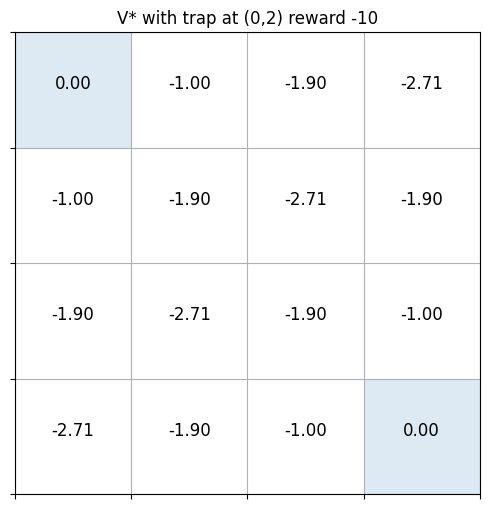

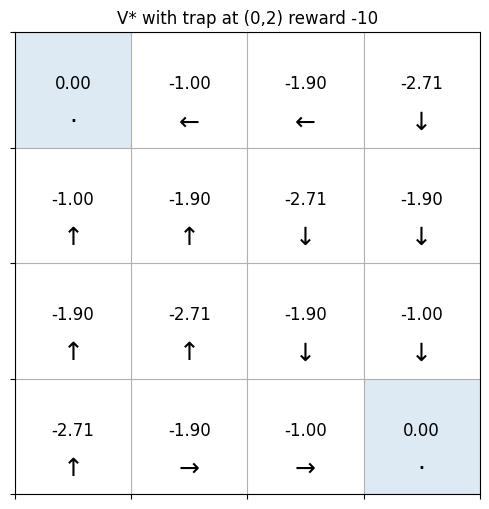

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'V* with trap at (0,2) reward -10'}>)

In [15]:
# Exercise B: trap cell with -10 on entry

from typing import Tuple

trap = (0,2)

env_trap = TrapGridworld(trap=trap)
V_trap, it_trap = value_iteration(env_trap, gamma=0.90, theta=1e-8)
pi_trap = greedy_policy_from_V(env_trap, V_trap, gamma=0.90)
print("Trap value iteration iters:", it_trap)
plot_grid_values_and_policy(env_trap, V_trap, None, title="V* with trap at (0,2) reward -10")
plot_grid_values_and_policy(env_trap, V_trap, pi_trap, title="V* with trap at (0,2) reward -10")

### Exercise C — Make the environment stochastic
- Modify `env.step` so that with probability 0.8 the intended action happens, and with probability 0.1 you slip left/right (relative to intended direction).
- What changes in $V^{*}$ and the greedy policy?

- Adding slip makes outcomes uncertain. Values typically become **more negative** (mistakes cost steps).
- The optimal policy may become more “cautious” near terminals or traps to reduce the chance of slipping into bad states.

State: (0, 1), Action: U, Delta: (-1, 0)
State: (0, 1), Action: L, Delta: (0, -1)
State: (0, 1), Action: R, Delta: (0, 1)
State: (0, 1), Action: D, Delta: (1, 0)
State: (0, 1), Action: R, Delta: (0, 1)
State: (0, 1), Action: L, Delta: (0, -1)
State: (0, 1), Action: L, Delta: (0, -1)
State: (0, 1), Action: D, Delta: (1, 0)
State: (0, 1), Action: U, Delta: (-1, 0)
State: (0, 1), Action: R, Delta: (0, 1)
State: (0, 1), Action: U, Delta: (-1, 0)
State: (0, 1), Action: D, Delta: (1, 0)
State: (0, 2), Action: U, Delta: (-1, 0)
State: (0, 2), Action: L, Delta: (0, -1)
State: (0, 2), Action: R, Delta: (0, 1)
State: (0, 2), Action: D, Delta: (1, 0)
State: (0, 2), Action: R, Delta: (0, 1)
State: (0, 2), Action: L, Delta: (0, -1)
State: (0, 2), Action: L, Delta: (0, -1)
State: (0, 2), Action: D, Delta: (1, 0)
State: (0, 2), Action: U, Delta: (-1, 0)
State: (0, 2), Action: R, Delta: (0, 1)
State: (0, 2), Action: U, Delta: (-1, 0)
State: (0, 2), Action: D, Delta: (1, 0)
State: (0, 3), Action: U, De

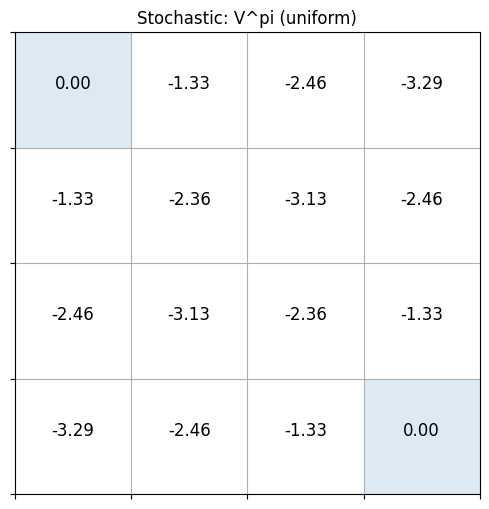

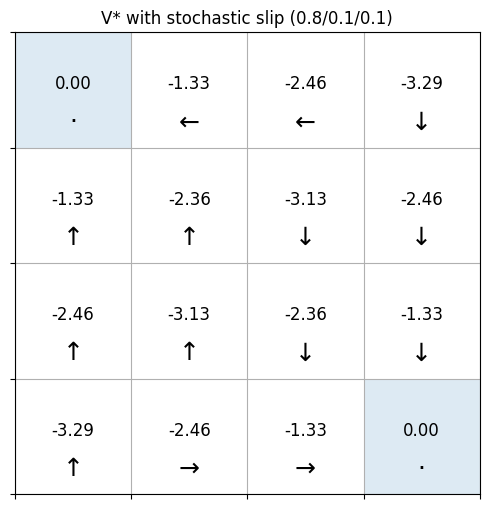

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'V* with stochastic slip (0.8/0.1/0.1)'}>)

In [16]:
# Exercise C: Make the environment stochastic

V_stoch, its = value_iteration_stochastic(env, gamma=0.9, theta=1e-8)
pi_stoch = greedy_policy_from_V(env, V_stoch, gamma=0.9)
print("Stochastic value iteration iters:", its)
plot_grid_values_and_policy(env, V_stoch, None, title="Stochastic: V^pi (uniform)")
plot_grid_values_and_policy(env, V_stoch, pi_stoch, title="V* with stochastic slip (0.8/0.1/0.1)")